# Experiment 1: Boundary Divergence — Same Architecture, Different Seeds

This notebook implements the core boundary divergence experiment from:
**"Boundary Divergence: A Geometric Diagnostic of Cross-Model Disagreement"**

## What this notebook does
Two GPT-2 sentiment classifiers are trained on SST-2 using identical
hyperparameters but different random seeds (seed=42 and seed=99).
Boundary divergence is computed for each input and tested as a predictor
of cross-model disagreement on three out-of-distribution datasets.

## Datasets
- **Training:** SST-2 (Stanford Sentiment Treebank)
- **OOD Evaluation:** IMDB, Amazon Polarity, TweetEval (500 sentences each)

## Key results
- Boundary score correlation across models: 0.920
- Average boundary divergence: 1.105
- High-divergence inputs are 2.0–2.6× more likely to produce disagreement
- All three OOD datasets show significant asymmetry (bootstrap CI excludes 1.0)

## Runtime
Approximately 30–45 minutes on a single GPU T4.

In [18]:
!pip install transformers datasets -q

In [19]:
!pip install --upgrade torch transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 4.9 MB/s eta 0:00:000:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 106.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 22.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 9.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 30.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 7.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 4.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [20]:
import torch
import numpy as np
from transformers import (
    GPT2Tokenizer,
    GPT2Model,
    GPT2ForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import load_dataset
import matplotlib.pyplot as plt
from collections import defaultdict

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Tokenizer setup
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# Load and tokenize training data
train_dataset = load_dataset("sst2", split="train")
val_dataset = load_dataset("sst2", split="validation")

def tokenize(batch):
    return tokenizer(
        batch["sentence"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

train_tokenized = train_dataset.map(tokenize, batched=True)
val_tokenized = val_dataset.map(tokenize, batched=True)
train_tokenized = train_tokenized.rename_column("label", "labels")
val_tokenized = val_tokenized.rename_column("label", "labels")
train_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("Data ready for training")
print(f"Train size: {len(train_tokenized)}")
print(f"Val size: {len(val_tokenized)}")

Using device: cuda


Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Data ready for training
Train size: 67349
Val size: 872


In [21]:
def train_model(seed, model_name="model"):
    torch.manual_seed(seed)
    
    model = GPT2ForSequenceClassification.from_pretrained(
        "gpt2",
        num_labels=2,
        ignore_mismatched_sizes=True
    )
    model.config.pad_token_id = tokenizer.eos_token_id
    
    # Note: output path is Kaggle-specific.
    # If running locally, change to e.g. output_dir=f"./outputs/{model_name}"
    training_args = TrainingArguments(
        output_dir=f"/kaggle/working/{model_name}",
        num_train_epochs=2,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=2e-5,
        seed=seed,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=100,
        report_to="none"
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
    )
    
    trainer.train()
    
    eval_results = trainer.evaluate()
    print(f"\n{model_name} final eval loss: {eval_results['eval_loss']:.4f}")
    
    return model

print("Training Model A (seed=42)...")
model_A = train_model(seed=42, model_name="model_A")

print("\nTraining Model B (seed=99)...")
model_B = train_model(seed=99, model_name="model_B")

print("\nBoth models trained independently.")
print(f"Weights identical: {torch.equal(list(model_A.parameters())[0], list(model_B.parameters())[0])}")

Training Model A (seed=42)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.462034,0.468583
2,0.352890,0.527954



model_A final eval loss: 0.5280

Training Model B (seed=99)...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.454299,0.459930
2,0.361966,0.516601



model_B final eval loss: 0.5166

Both models trained independently.
Weights identical: False


In [22]:
dataset = load_dataset("sst2", split="validation")
sentences = [x["sentence"] for x in dataset]
labels = [x["label"] for x in dataset]

# just look at first 5 to confirm it loaded
for s, l in zip(sentences[:5], labels[:5]):
    print(f"Label {l}: {s}")

Label 1: it 's a charming and often affecting journey . 
Label 0: unflinchingly bleak and desperate 
Label 1: allows us to hope that nolan is poised to embark a major career as a commercial yet inventive filmmaker . 
Label 1: the acting , costumes , music , cinematography and sound are all astounding given the production 's austere locales . 
Label 0: it 's slow -- very , very slow . 


In [23]:
# use first 2000 sentences to keep things fast
sample_sentences = sentences[:2000]
sample_labels = labels[:2000]

# tokenize
encoded = tokenizer(
    sample_sentences,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors="pt"
)

print(f"Input shape: {encoded['input_ids'].shape}")

Input shape: torch.Size([872, 61])


In [24]:
def get_boundary_scores(model, encoded):
    model.eval()
    scores = []
    
    for i in range(len(encoded['input_ids'])):
        input_ids = encoded['input_ids'][i].unsqueeze(0).to(device)
        attention_mask = encoded['attention_mask'][i].unsqueeze(0).to(device)
        
        inputs_embeds = model.transformer.wte(input_ids).detach().requires_grad_(True).to(device)
        
        outputs = model(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask
        )
        
        logits = outputs.logits
        margin = logits[0, 1] - logits[0, 0]
        margin.backward()
        
        score = inputs_embeds.grad.norm().item()
        scores.append(score)
        
        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{len(encoded['input_ids'])} sentences...")
    
    return np.array(scores)

print("Computing boundary scores for Model A...")
scores_A = get_boundary_scores(model_A, encoded)

print("Computing boundary scores for Model B...")
scores_B = get_boundary_scores(model_B, encoded)

print("Done.")

Computing boundary scores for Model A...
Processed 50/872 sentences...
Processed 100/872 sentences...
Processed 150/872 sentences...
Processed 200/872 sentences...
Processed 250/872 sentences...
Processed 300/872 sentences...
Processed 350/872 sentences...
Processed 400/872 sentences...
Processed 450/872 sentences...
Processed 500/872 sentences...
Processed 550/872 sentences...
Processed 600/872 sentences...
Processed 650/872 sentences...
Processed 700/872 sentences...
Processed 750/872 sentences...
Processed 800/872 sentences...
Processed 850/872 sentences...
Computing boundary scores for Model B...
Processed 50/872 sentences...
Processed 100/872 sentences...
Processed 150/872 sentences...
Processed 200/872 sentences...
Processed 250/872 sentences...
Processed 300/872 sentences...
Processed 350/872 sentences...
Processed 400/872 sentences...
Processed 450/872 sentences...
Processed 500/872 sentences...
Processed 550/872 sentences...
Processed 600/872 sentences...
Processed 650/872 sen

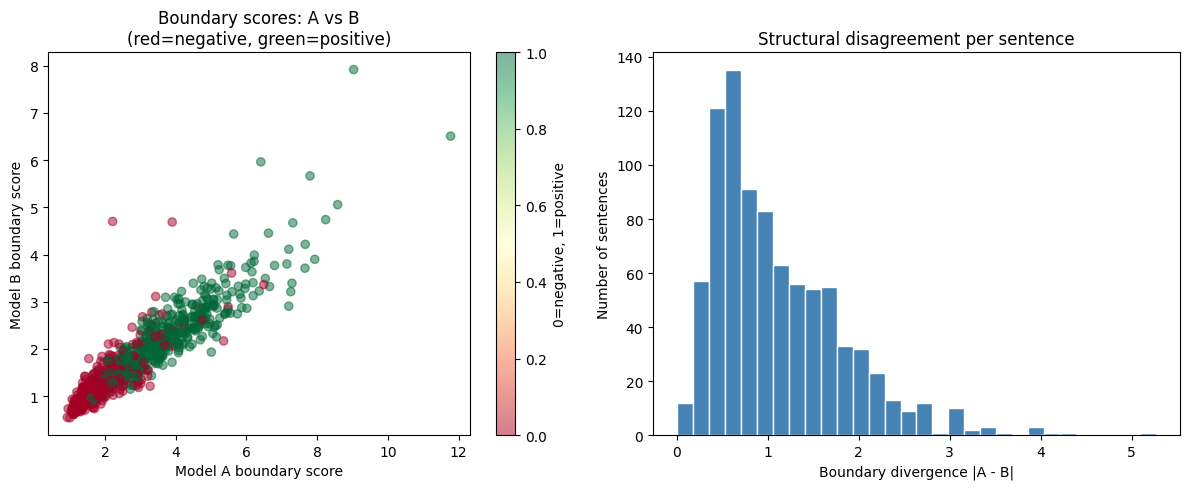

Correlation between Model A and B boundary scores: 0.920
Average divergence: 1.105

Top 5 most structurally divergent sentences:
  [784] divergence=5.269 | 'very psychoanalytical -- provocatively so -- and also refreshingly literary . '
  [674] divergence=4.294 | 'atom egoyan has conjured up a multilayered work that tackles any number of fascinating issues '
  [239] divergence=4.044 | 'brilliantly explores the conflict between following one 's heart and following the demands of tradition . '
  [740] divergence=4.037 | 'jose campanella delivers a loosely autobiographical story brushed with sentimentality but brimming with gentle humor , bittersweet pathos , and lyric moments that linger like snapshots of memory . '
  [300] divergence=3.947 | 'fun , flip and terribly hip bit of cinematic entertainment . '


In [25]:
plt.figure(figsize=(12, 5))

# scatter plot: model A score vs model B score per sentence
plt.subplot(1, 2, 1)
plt.scatter(scores_A, scores_B, alpha=0.5, c=sample_labels, cmap='RdYlGn')
plt.xlabel("Model A boundary score")
plt.ylabel("Model B boundary score")
plt.title("Boundary scores: A vs B\n(red=negative, green=positive)")
plt.colorbar(label="0=negative, 1=positive")

# divergence per sentence
boundary_divergence = np.abs(scores_A - scores_B)

plt.subplot(1, 2, 2)
plt.hist(boundary_divergence, bins=30, color='steelblue', edgecolor='white')
plt.xlabel("Boundary divergence |A - B|")
plt.ylabel("Number of sentences")
plt.title("Structural disagreement per sentence")

plt.tight_layout()
plt.show()

# print key numbers
correlation = np.corrcoef(scores_A, scores_B)[0,1]
print(f"Correlation between Model A and B boundary scores: {correlation:.3f}")
print(f"Average divergence: {boundary_divergence.mean():.3f}")
print(f"\nTop 5 most structurally divergent sentences:")
top_5 = boundary_divergence.argsort()[-5:][::-1]
for idx in top_5:
    print(f"  [{idx}] divergence={boundary_divergence[idx]:.3f} | '{sample_sentences[idx]}'")

In [26]:
def get_token_boundary_scores(model, encoded, idx):
    model.eval()
    input_ids = encoded['input_ids'][idx].unsqueeze(0).to(device)
    attention_mask = encoded['attention_mask'][idx].unsqueeze(0).to(device)
    
    inputs_embeds = model.transformer.wte(input_ids).detach().requires_grad_(True).to(device)
    
    outputs = model(inputs_embeds=inputs_embeds, attention_mask=attention_mask)
    margin = outputs.logits[0, 1] - outputs.logits[0, 0]
    margin.backward()
    
    token_scores = inputs_embeds.grad[0].norm(dim=-1).detach().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu())
    
    return tokens, token_scores

top_20_idx = np.abs(scores_A - scores_B).argsort()[-20:][::-1]

token_divergence = defaultdict(list)

for idx in top_20_idx:
    tokens_A, scores_tok_A = get_token_boundary_scores(model_A, encoded, idx)
    tokens_B, scores_tok_B = get_token_boundary_scores(model_B, encoded, idx)
    
    token_divergence_scores = np.abs(scores_tok_A - scores_tok_B)
    
    for token, score in zip(tokens_A, token_divergence_scores):
        clean_token = token.strip().lower()
        for char in ['\u0120', '\u0121', '\u0106', '\u0107', ' ']:
            clean_token = clean_token.replace(char, '')
        
        if (clean_token and
            clean_token not in ['<|endoftext|>', '...', '.', ',', '?', '!', "''", '``'] and
            len(clean_token) > 1):
            token_divergence[clean_token].append(score)

token_avg = {t: np.mean(v) for t, v in token_divergence.items() if len(v) >= 2}
top_tokens = sorted(token_avg.items(), key=lambda x: x[1], reverse=True)[:20]

print("Top 20 tokens by boundary divergence:")
print()
for token, score in top_tokens:
    bar = "#" * min(int(score), 50)
    print(f"  {token:20s} {score:.3f}  {bar}")

Top 20 tokens by boundary divergence:

  fun                  0.911  
  has                  0.888  
  --                   0.772  
  br                   0.748  
  following            0.685  
  it                   0.546  
  the                  0.490  
  prov                 0.469  
  izing                0.451  
  and                  0.428  
  so                   0.411  
  eng                  0.364  
  ch                   0.350  
  in                   0.341  
  performances         0.331  
  is                   0.323  
  of                   0.305  
  film                 0.298  
  ing                  0.292  
  to                   0.247  


In [27]:
# load all three OOD datasets
print("Loading OOD datasets...")

imdb = load_dataset("imdb", split="test[:500]")
imdb_sentences = [x["text"][:300] for x in imdb]
imdb_labels = [x["label"] for x in imdb]

amazon = load_dataset("amazon_polarity", split="test[:500]")
amazon_sentences = [x["content"][:300] for x in amazon]
amazon_labels = [x["label"] for x in amazon]

tweets = load_dataset("tweet_eval", "sentiment", split="test[:500]")
tweet_sentences = [x["text"][:300] for x in tweets]
tweet_labels = [x["label"] for x in tweets]

print(f"IMDB: {len(imdb_sentences)} sentences")
print(f"Amazon: {len(amazon_sentences)} sentences")
print(f"Tweets: {len(tweet_sentences)} sentences")

print("\nExamples:")
print(f"IMDB:   {imdb_sentences[0][:80]}")
print(f"Amazon: {amazon_sentences[0][:80]}")
print(f"Tweet:  {tweet_sentences[0][:80]}")

Loading OOD datasets...
IMDB: 500 sentences
Amazon: 500 sentences
Tweets: 500 sentences

Examples:
IMDB:   I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually 
Amazon: My lovely Pat has one of the GREAT voices of her generation. I have listened to 
Tweet:  @user @user what do these '1/2 naked pics' have to do with anything? They're not


In [28]:
def get_predictions(model, encoded):
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for i in range(len(encoded['input_ids'])):
            input_ids = encoded['input_ids'][i].unsqueeze(0).to(device)
            attention_mask = encoded['attention_mask'][i].unsqueeze(0).to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            
            pred = outputs.logits.argmax(dim=-1).item()
            predictions.append(pred)
    
    return np.array(predictions)

In [29]:
def run_asymmetry_test(model_A, model_B, sentences, labels, dataset_name, boundary_divergence_train):
    print(f"\nProcessing {dataset_name}...")
    
    enc = tokenizer(
        sentences,
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors="pt"
    )
    
    preds_A = get_predictions(model_A, enc)
    preds_B = get_predictions(model_B, enc)
    disagreement = (preds_A != preds_B).astype(int)
    
    print(f"  Computing boundary scores...")
    ood_scores_A = get_boundary_scores(model_A, enc)
    ood_scores_B = get_boundary_scores(model_B, enc)
    ood_divergence = np.abs(ood_scores_A - ood_scores_B)
    
    median_div = np.median(ood_divergence)
    high_div = ood_divergence > median_div
    low_div = ood_divergence <= median_div
    
    p_high = disagreement[high_div].mean()
    p_low = disagreement[low_div].mean()
    ratio = p_high / (p_low + 1e-10)
    
    print(f"  Disagreement rate: {disagreement.mean()*100:.1f}%")
    print(f"  P(disagree|HIGH divergence): {p_high*100:.1f}%")
    print(f"  P(disagree|LOW divergence):  {p_low*100:.1f}%")
    print(f"  Ratio: {ratio:.2f}x")
    
    return {
        'name': dataset_name,
        'disagreement_rate': disagreement.mean(),
        'p_high': p_high,
        'p_low': p_low,
        'ratio': ratio,
        'divergence': ood_divergence,
        'disagreement': disagreement
    }

results = []

results.append(run_asymmetry_test(
    model_A, model_B, imdb_sentences, imdb_labels, "IMDB", scores_A))

results.append(run_asymmetry_test(
    model_A, model_B, amazon_sentences, amazon_labels, "Amazon", scores_A))

results.append(run_asymmetry_test(
    model_A, model_B, tweet_sentences, tweet_labels, "Tweets", scores_A))

print("\nDone.")


Processing IMDB...
  Computing boundary scores...
Processed 50/500 sentences...
Processed 100/500 sentences...
Processed 150/500 sentences...
Processed 200/500 sentences...
Processed 250/500 sentences...
Processed 300/500 sentences...
Processed 350/500 sentences...
Processed 400/500 sentences...
Processed 450/500 sentences...
Processed 500/500 sentences...
Processed 50/500 sentences...
Processed 100/500 sentences...
Processed 150/500 sentences...
Processed 200/500 sentences...
Processed 250/500 sentences...
Processed 300/500 sentences...
Processed 350/500 sentences...
Processed 400/500 sentences...
Processed 450/500 sentences...
Processed 500/500 sentences...
  Disagreement rate: 12.6%
  P(disagree|HIGH divergence): 18.0%
  P(disagree|LOW divergence):  7.2%
  Ratio: 2.50x

Processing Amazon...
  Computing boundary scores...
Processed 50/500 sentences...
Processed 100/500 sentences...
Processed 150/500 sentences...
Processed 200/500 sentences...
Processed 250/500 sentences...
Processed

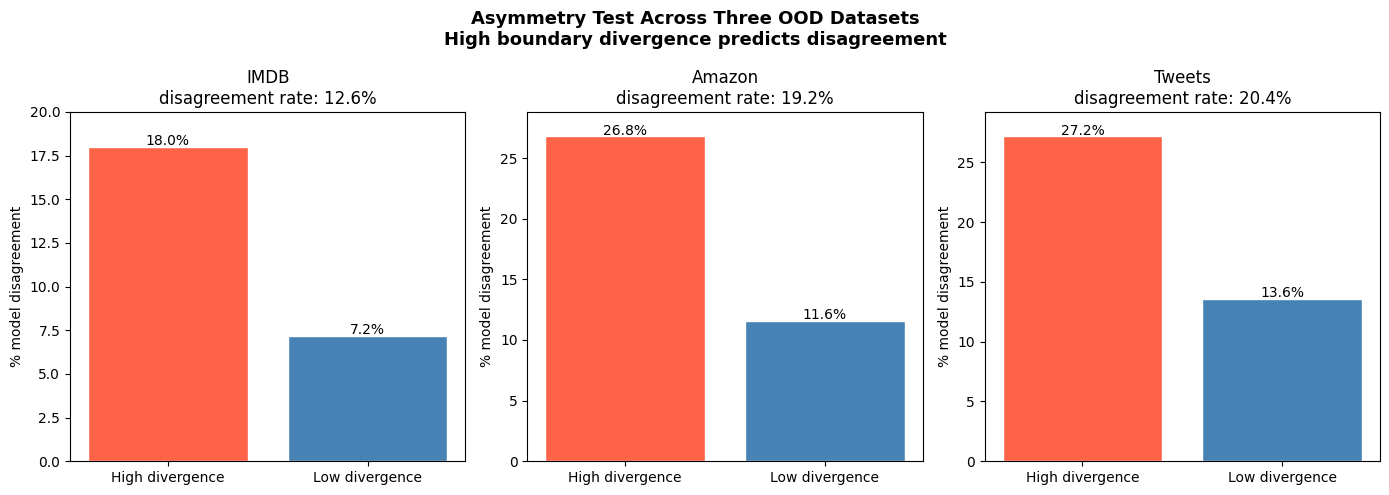


Summary table:
Dataset    Disagree rate   P(dis|HIGH)  P(dis|LOW)   Story               
----------------------------------------------------------------------
IMDB                  12.6         18.0          7.2 2.5x effect         
Amazon                19.2         26.8         11.6 2.3x effect         
Tweets                20.4         27.2         13.6 2.0x effect         


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, (ax, result) in enumerate(zip(axes, results)):
    bars = ax.bar(
        ['High divergence', 'Low divergence'],
        [result['p_high']*100, result['p_low']*100],
        color=['tomato', 'steelblue'],
        edgecolor='white'
    )
    ax.set_title(f"{result['name']}\ndisagreement rate: {result['disagreement_rate']*100:.1f}%")
    ax.set_ylabel("% model disagreement")
    ax.set_ylim(0, max(result['p_high']*100 + 2, 5))
    
    for bar, val in zip(bars, [result['p_high']*100, result['p_low']*100]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{val:.1f}%',
                ha='center', fontsize=10)

plt.suptitle("Asymmetry Test Across Three OOD Datasets\nHigh boundary divergence predicts disagreement",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSummary table:")
print(f"{'Dataset':10s} {'Disagree rate':15s} {'P(dis|HIGH)':12s} {'P(dis|LOW)':12s} {'Story':20s}")
print("-" * 70)
for r in results:
    if r['p_low'] == 0 and r['p_high'] > 0:
        story = "perfect asymmetry"
    elif r['p_high'] == 0 and r['p_low'] == 0:
        story = "too simple to fail"
    else:
        ratio = r['p_high'] / r['p_low']
        story = f"{ratio:.1f}x effect"
    print(f"{r['name']:10s} {r['disagreement_rate']*100:15.1f} {r['p_high']*100:12.1f} {r['p_low']*100:12.1f} {story:20s}")

In [31]:
def bootstrap_asymmetry(disagreement, divergence, n_bootstrap=200):
    ratios = []
    n = len(disagreement)
    
    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        dis = disagreement[idx]
        div = divergence[idx]
        
        median_div = np.median(div)
        high = div > median_div
        low = div <= median_div
        
        p_high = dis[high].mean()
        p_low = dis[low].mean()
        ratio = p_high / (p_low + 1e-10)
        ratios.append(ratio)
    
    ratios = np.array(ratios)
    ci_low = np.percentile(ratios, 2.5)
    ci_high = np.percentile(ratios, 97.5)
    mean = np.mean(ratios)
    
    return mean, ci_low, ci_high

print("Bootstrap confidence intervals (95%) for asymmetry ratio")
print("=" * 60)

for r in results:
    mean, ci_low, ci_high = bootstrap_asymmetry(
        r['disagreement'],
        r['divergence']
    )
    print(f"\n{r['name']}:")
    print(f"  Ratio: {mean:.2f}x  (95% CI: {ci_low:.2f}x - {ci_high:.2f}x)")
    print(f"  Significant: {'YES' if ci_low > 1.0 else 'NO'}")

Bootstrap confidence intervals (95%) for asymmetry ratio

IMDB:
  Ratio: 2.60x  (95% CI: 1.52x - 4.73x)
  Significant: YES

Amazon:
  Ratio: 2.22x  (95% CI: 1.35x - 3.37x)
  Significant: YES

Tweets:
  Ratio: 2.05x  (95% CI: 1.42x - 2.89x)
  Significant: YES


In [32]:
print("Disagreement rate by boundary divergence decile")
print("=" * 60)

for r in results:
    print(f"\n{r['name']}:")
    quantiles = np.percentile(r['divergence'], np.linspace(0, 100, 11))
    for k in range(10):
        mask = (r['divergence'] >= quantiles[k])
        if k < 9:
            mask = mask & (r['divergence'] < quantiles[k+1])
        rate = r['disagreement'][mask].mean() * 100
        print(f"  {k*10}-{(k+1)*10}%: {rate:.1f}%")

Disagreement rate by boundary divergence decile

IMDB:
  0-10%: 4.0%
  10-20%: 2.0%
  20-30%: 10.0%
  30-40%: 8.0%
  40-50%: 12.0%
  50-60%: 18.0%
  60-70%: 14.0%
  70-80%: 18.0%
  80-90%: 16.0%
  90-100%: 24.0%

Amazon:
  0-10%: 10.0%
  10-20%: 12.0%
  20-30%: 6.0%
  30-40%: 14.0%
  40-50%: 16.0%
  50-60%: 22.0%
  60-70%: 26.0%
  70-80%: 26.0%
  80-90%: 36.0%
  90-100%: 24.0%

Tweets:
  0-10%: 14.0%
  10-20%: 12.0%
  20-30%: 8.0%
  30-40%: 16.0%
  40-50%: 18.0%
  50-60%: 22.0%
  60-70%: 30.0%
  70-80%: 26.0%
  80-90%: 22.0%
  90-100%: 36.0%
